# **Convolutional Autoencoder for T-Shirt Image Reconstruction**

In [73]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Required Libraries**

In [74]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from sklearn.metrics import mean_squared_error

folder = "/content/drive/MyDrive/deep_learning_project1/final_tshirts"

## **Data Loading**


In [87]:
def load_images(folder):
    images = []
    for file in os.listdir(folder):
        if file.endswith((".jpg", ".jpeg", ".png")):
            img = load_img(os.path.join(folder, file))
            img = img_to_array(img)
            images.append(img)
    return np.array(images, dtype="uint8")

X = load_images(folder)
print("Number of images:", len(X))
print("Shape:", X.shape)

Number of images: 219
Shape: (219, 64, 64, 3)


## **Train/ Test**


In [76]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (175, 64, 64, 3)
Test: (44, 64, 64, 3)


## **Visualizations Original Images**


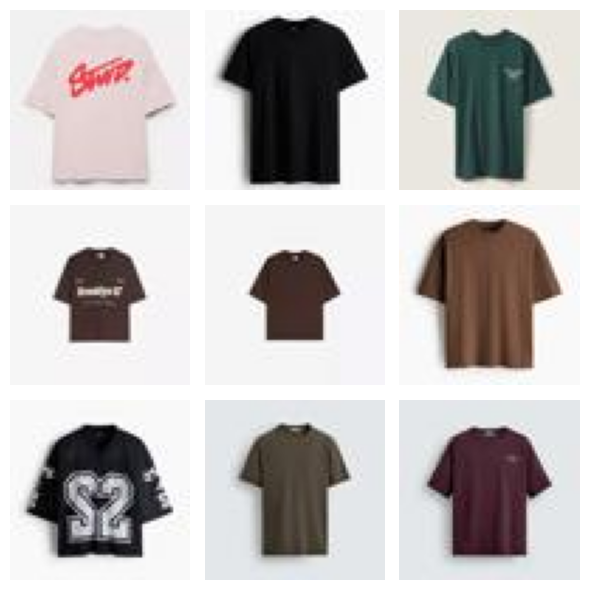

In [77]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()


## **Data Augmentation**

In [78]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

To improve model robustness, small random transformations are applied to the training images:

- Rotation (±10 degrees)
- Width and height shift (±5%)
- Zoom (±10%)
- Horizontal flip

## **Data Augmentation Visualization**

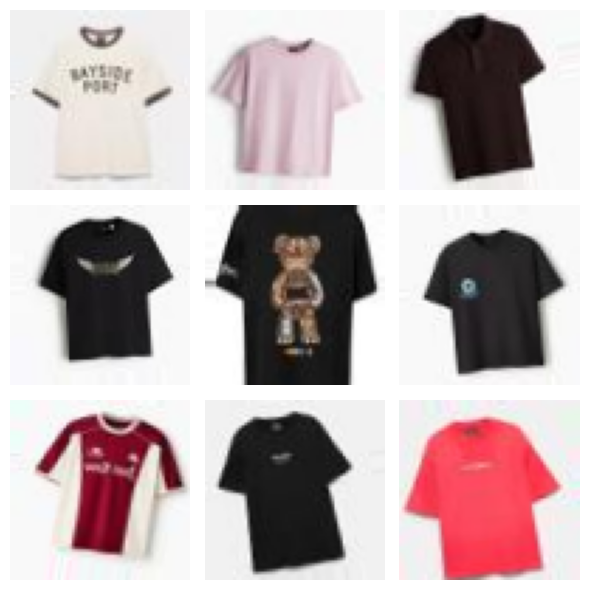

In [79]:
X_batch = next(datagen.flow(X_train, batch_size=9))

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_batch[i].astype("uint8"))
    plt.axis("off")
plt.tight_layout()
plt.show()

## **Normalization**

In [80]:
X_train_norm = X_train.astype("float32") / 255.
X_test_norm = X_test.astype("float32") / 255.

## **Autoencoder Architecture**

In [81]:
autoencoder = Sequential(name="Autoencoder_Tshirts")

# Encoder
autoencoder.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)))
autoencoder.add(MaxPooling2D((2,2), padding='same'))  # 32x32
autoencoder.add(Conv2D(64, (3,3), activation='relu', padding='same'))
autoencoder.add(MaxPooling2D((2,2), padding='same'))  # 16x16
autoencoder.add(Conv2D(128, (3,3), activation='relu', padding='same'))
autoencoder.add(MaxPooling2D((2,2), padding='same'))  # 8x8

# Decoder
autoencoder.add(Conv2D(128, (3,3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D((2,2)))  # 16x16
autoencoder.add(Conv2D(64, (3,3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D((2,2)))  # 32x32
autoencoder.add(Conv2D(32, (3,3), activation='relu', padding='same'))
autoencoder.add(UpSampling2D((2,2)))  # 64x64
autoencoder.add(Conv2D(3, (3,3), activation='sigmoid', padding='same'))

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()


Model: "Autoencoder_Tshirts"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

**Encoder:**
- 3 Conv2D layers with increasing filters (32 → 64 → 128)
- MaxPooling2D layers to downsample the image
- Activation: ReLU

**Decoder:**
- 3 Conv2D layers with decreasing filters (128 → 64 → 32)
- UpSampling2D layers to restore the original size
- Output layer: Conv2D with 3 filters and Sigmoid activation

- Loss function: Mean Squared Error (MSE)
- Optimizer: Adam

## **Model Training**

In [82]:
history = autoencoder.fit(
    datagen.flow(X_train_norm, X_train_norm, batch_size=32),
    steps_per_epoch=len(X_train_norm)//32,
    epochs=50,
    validation_data=(X_test_norm, X_test_norm)
)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.1283 - val_loss: 0.0962
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.0837 - val_loss: 0.0860
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 696ms/step - loss: 0.0706 - val_loss: 0.0629
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0621 - val_loss: 0.0536
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 692ms/step - loss: 0.0504 - val_loss: 0.0293
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 0.0310 - val_loss: 0.0274
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - loss: 0.0330 - val_loss: 0.0544
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0550 - val_loss: 0.0234
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 776ms/step - loss: 0.0383 - val_loss: 0.0236
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - loss: 0.0199 - val_loss: 0.0242
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 695ms/step - loss: 0.0305 - val_loss: 0.0268
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - loss: 0.0322 - val_loss: 0.0228

- Train the autoencoder using the training images as both input and target.
- Validation is done on the test set.
- Data augmentation is applied in real time using `datagen.flow()`.

In [83]:
#history = autoencoder.fit(
    #X_train_norm, X_train_norm,
    #epochs=50,
    #batch_size=32,
    #shuffle=True,
    #validation_data=(X_test_norm, X_test_norm)
#)


## **Training Loss**

dict_keys(['loss', 'val_loss'])


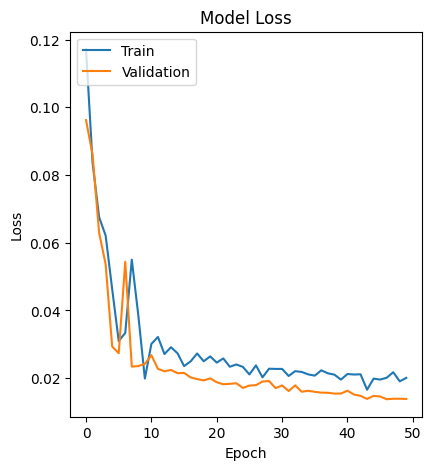

In [84]:
def plot_history(history):

    plt.figure(figsize=(10, 5))

    # summarize history for loss
    plt.subplot(122)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

print(history.history.keys())
plot_history(history)

## **Image Reconstruction**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step


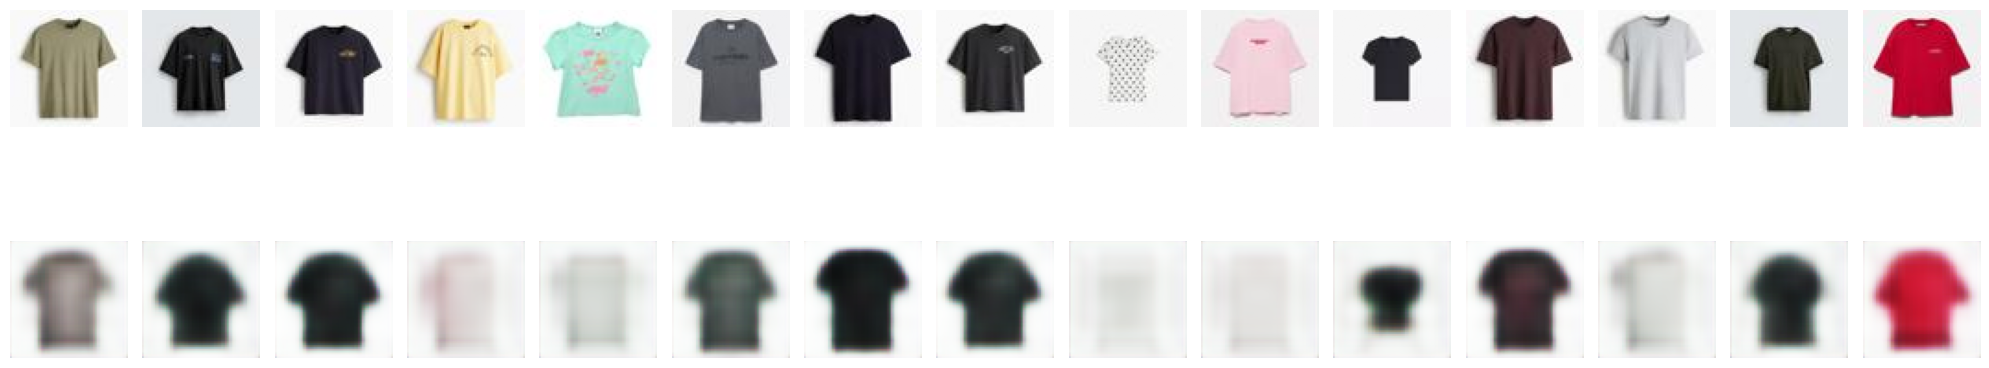

In [85]:
import matplotlib.pyplot as plt

n = 15
decoded_imgs = autoencoder.predict(X_test_norm[:n])

plt.figure(figsize=(20,6))
for i in range(n):
    # original
    plt.subplot(2, n, i+1)
    plt.imshow(X_test_norm[i])
    plt.axis('off')

    # reconstructed
    plt.subplot(2, n, i+n+1)
    plt.imshow(decoded_imgs[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [86]:
mse = np.mean((X_test_norm[:len(decoded_imgs)] - decoded_imgs) ** 2)
print("MSE promedio de reconstrucción:", mse)


MSE promedio de reconstrucción: 0.010317883
